#Задание 4.1. Анализ данных с помощью Dask


## 4.1.1. Настройка среды и рабочего каталога


In [2]:
# Установка Dask с полным набором зависимостей
!pip install "dask[complete]"

import sys
import os
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import pandas as pd

# Если работаете в Google Colab, подключите диск
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
Mounted at /content/drive


## 4.1.2. Загрузка данных


In [3]:
# Чтение CSV файла с помощью Dask
# Обратите внимание: данные не загружаются в память сразу
df = dd.read_csv('/content/austinHousingData.csv')

# Просмотр структуры (метаданных)
df

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasCooling,hasGarage,hasHeating,hasSpa,hasView,homeType,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,latest_saledate,latest_salemonth,latest_saleyear,latestPriceSource,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,numOfParkingFeatures,numOfPatioAndPorchFeatures,numOfSecurityFeatures,numOfWaterfrontFeatures,numOfWindowFeatures,numOfCommunityFeatures,lotSizeSqFt,livingAreaSqFt,numOfPrimarySchools,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,int64,string,float64,float64,float64,int64,bool,bool,bool,bool,bool,bool,string,int64,int64,float64,int64,string,int64,int64,string,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int64,int64,int64,int64,float64,float64,int64,int64,float64,int64,int64,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [4]:
len(df)

15171

In [5]:
print("Количество строк:", df.shape[0].compute())
print("Количество столбцов:", df.shape[1])

Количество строк: 15171
Количество столбцов: 47


In [6]:
with ProgressBar():
    avg_price = df['latestPrice'].mean().compute()

print("Средняя цена:", round(avg_price, 2))

[########################################] | 100% Completed | 532.97 ms
Средняя цена: 512767.74


## 4.1.3. Проверка качества данных


In [7]:
# Подсчет пропущенных значений (построение графа вычислений)
missing_values = df.isnull().sum()

# Вычисление процента пропусков
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)

# Запуск вычислений с прогресс-баром
with ProgressBar():
    missing_count_percent = missing_count.compute()

print(missing_count_percent)

[########################################] | 100% Completed | 562.99 ms
zpid                          0.000000
city                          0.000000
streetAddress                 0.000000
zipcode                       0.000000
description                   0.013183
latitude                      0.000000
longitude                     0.000000
propertyTaxRate               0.000000
garageSpaces                  0.000000
hasAssociation                0.000000
hasCooling                    0.000000
hasGarage                     0.000000
hasHeating                    0.000000
hasSpa                        0.000000
hasView                       0.000000
homeType                      0.000000
parkingSpaces                 0.000000
yearBuilt                     0.000000
latestPrice                   0.000000
numPriceChanges               0.000000
latest_saledate               0.000000
latest_salemonth              0.000000
latest_saleyear               0.000000
latestPriceSource             0

## 4.1.4. Очистка данных



In [8]:
columns_to_drop = missing_count_percent[missing_count_percent > 60].index.tolist()
print("Удаляемые столбцы:", columns_to_drop)

with ProgressBar():
    df_dropped = df.drop(columns=columns_to_drop).persist()

df_dropped.head()

Удаляемые столбцы: []
[########################################] | 100% Completed | 527.41 ms


,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


# Задание 4.2. Визуализация ориентированных ациклических графов (DAG)


## 4.2.1. Визуализация DAG с одним узлом


5


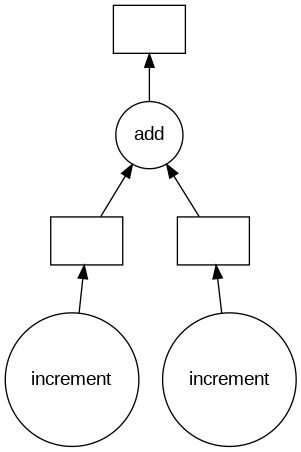

In [ ]:
import dask.delayed as delayed

def increment(i):
    return i + 1

def add(x, y):
    return x + y

# Создание отложенных объектов
x = delayed(increment)(1)
y = delayed(increment)(2)
z = delayed(add)(x, y)

# Визуализация графа
z.visualize()

# Получение результата
print(z.compute())

from IPython.display import Image
Image("mydask.png")

## 4.2.2. Визуализация сложного DAG


Результат: 40


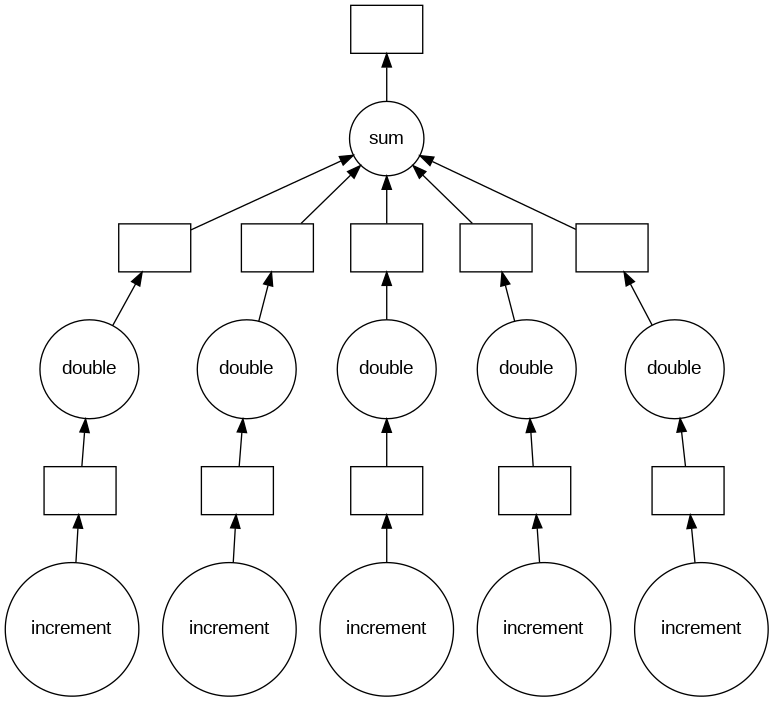

In [ ]:
data = [1, 2, 3, 4, 5]

# Слой 1: Инкремент каждого элемента
layer1 = [delayed(increment)(i) for i in data]

# Агрегация слоя 1 (сумма)
total1 = delayed(sum)(layer1)
total1.visualize() # Можно раскомментировать для проверки

def double(x):
    return x * 2

# Слой 2: Удвоение результатов из слоя 1 (пример логики,
# здесь можно использовать output предыдущего шага или строить новую цепочку)
# В примере из методички строится цепочка:
layer2 = [delayed(double)(j) for j in layer1]
total2 = delayed(sum)(layer2)

# Визуализация полного графа
#total2.visualize()
total2.visualize(filename="mygraph", format="png")

from IPython.display import Image
Image("mygraph.png")
# Вычисление
result = total2.compute()
print("Результат:", result)


from IPython.display import Image
Image("mygraph.png")

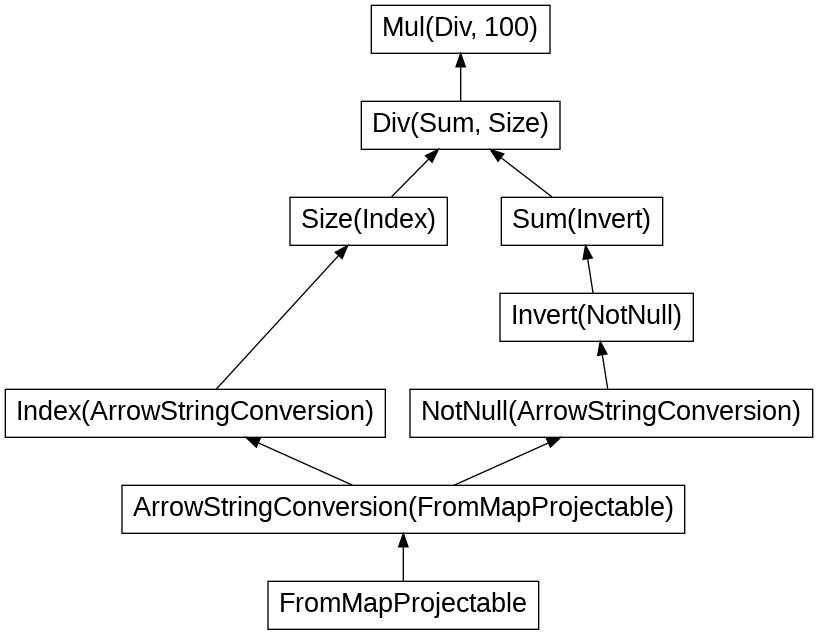

In [ ]:
# Визуализация графа подсчета пропусков из первой части
missing_count.visualize(filename="my4", format="png")

Image("my4.png")

# Вариант 6


## Шаг 0. Подготовка окружения

In [37]:
!pip install "dask[complete]" graphviz

In [38]:
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:32939
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35917'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34153'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35659 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35659
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:46484
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37825 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37825
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32939,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35659,Total threads: 2
Dashboard: http://127.0.0.1:46615/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:35917,


## Шаг 1. EXTRACT (Извлечение)

In [9]:
df = dd.read_csv('/content/austinHousingData.csv')

df

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasCooling,hasGarage,hasHeating,hasSpa,hasView,homeType,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,latest_saledate,latest_salemonth,latest_saleyear,latestPriceSource,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,numOfParkingFeatures,numOfPatioAndPorchFeatures,numOfSecurityFeatures,numOfWaterfrontFeatures,numOfWindowFeatures,numOfCommunityFeatures,lotSizeSqFt,livingAreaSqFt,numOfPrimarySchools,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,int64,string,float64,float64,float64,int64,bool,bool,bool,bool,bool,bool,string,int64,int64,float64,int64,string,int64,int64,string,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int64,int64,int64,int64,float64,float64,int64,int64,float64,int64,int64,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## Шаг 2. Transform (Трансформация и очистка данных)

In [45]:
missing_values = df.isnull().sum()

mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)

print(missing_count_percent)

zpid                          0.000000
city                          0.000000
streetAddress                 0.000000
zipcode                       0.000000
description                   0.013183
latitude                      0.000000
longitude                     0.000000
propertyTaxRate               0.000000
garageSpaces                  0.000000
hasAssociation                0.000000
hasCooling                    0.000000
hasGarage                     0.000000
hasHeating                    0.000000
hasSpa                        0.000000
hasView                       0.000000
homeType                      0.000000
parkingSpaces                 0.000000
yearBuilt                     0.000000
latestPrice                   0.000000
numPriceChanges               0.000000
latest_saledate               0.000000
latest_salemonth              0.000000
latest_saleyear               0.000000
latestPriceSource             0.000000
numOfPhotos                   0.000000
numOfAccessibilityFeature

In [46]:
columns_to_drop = missing_percent_result[missing_percent_result > 60].index.tolist()

print("Столбцы для удаления:", columns_to_drop)

Столбцы для удаления: []


In [11]:
df_cleaned = df.drop(columns=columns_to_drop)

df_cleaned

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasCooling,hasGarage,hasHeating,hasSpa,hasView,homeType,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,latest_saledate,latest_salemonth,latest_saleyear,latestPriceSource,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,numOfParkingFeatures,numOfPatioAndPorchFeatures,numOfSecurityFeatures,numOfWaterfrontFeatures,numOfWindowFeatures,numOfCommunityFeatures,lotSizeSqFt,livingAreaSqFt,numOfPrimarySchools,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,int64,string,float64,float64,float64,int64,bool,bool,bool,bool,bool,bool,string,int64,int64,float64,int64,string,int64,int64,string,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int64,int64,int64,int64,float64,float64,int64,int64,float64,int64,int64,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


## Шаг 3. Load (Сохранение результатов пайплайна)

In [48]:
output_path = "/content/cleaned_dataset.parquet"

with ProgressBar():
    df_cleaned.to_parquet(output_path, engine="pyarrow")

## Шаг 4. Визуализация направленных ациклических графов (DAG)

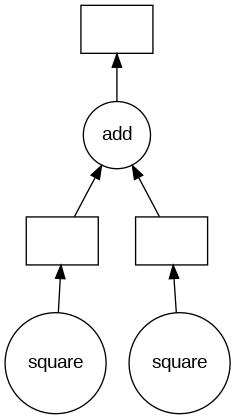

In [52]:
@delayed
def square(x):
    return x ** 2

@delayed
def add(a, b):
    return a + b

x = square(4)
y = square(5)
z = add(x, y)

z.visualize(filename="my6", format="png")
z.compute()

Image("my6.png")


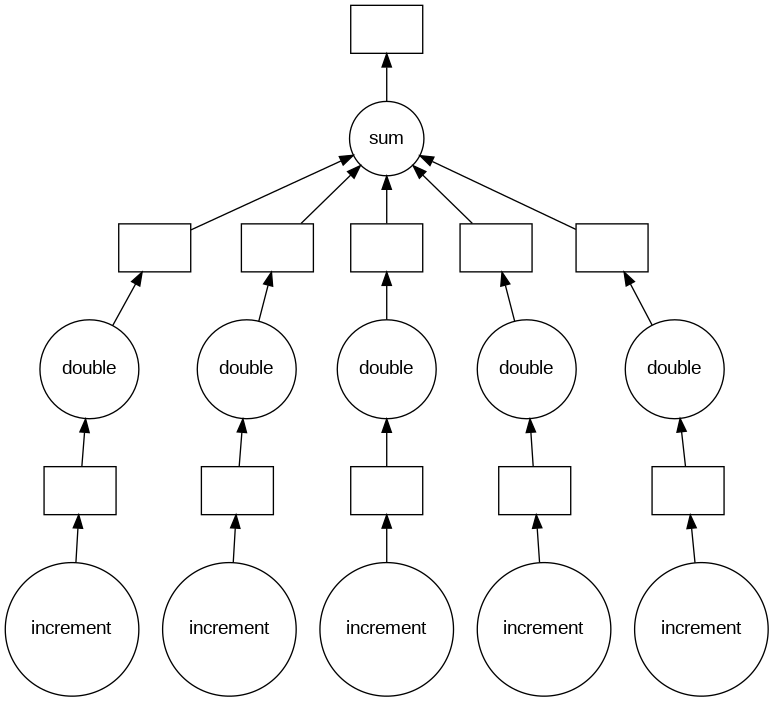

In [53]:
data = [1, 2, 3, 4, 5]

@delayed
def increment(x):
    return x + 1

@delayed
def double(x):
    return x * 2

# map
layer1 = [increment(i) for i in data]

# второй уровень
layer2 = [double(j) for j in layer1]

# reduce
total = delayed(sum)(layer2)

total.visualize(filename="my66", format="png")
total.compute()
Image("my66.png")



# Бизнес-контекст
Датасет содержит объявления о продаже жилой недвижимости в Austin.
Цель анализа — выявить ключевые факторы, влияющие на цену дома, а также подготовить данные для дальнейшей визуализации в BI-системе (дашборд для агентства недвижимости).

## E — Extract
Уже реализовано в этом блокноте

## T — Transform

In [57]:
#2.1 Базовые метрики рынка
with ProgressBar():
    avg_price = df_dropped['latestPrice'].mean().compute()
    median_price = df_dropped['latestPrice'].median().compute()
    avg_area = df_dropped['livingAreaSqFt'].mean().compute()

print("Средняя цена:", round(avg_price,2))
print("Медианная цена:", round(median_price,2))
print("Средняя площадь:", round(avg_area,2))

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask dire

Средняя цена: 512767.74
Медианная цена: 405000.0
Средняя площадь: 2208.32


In [59]:
#2.2 Цена за квадратный фут
df_dropped['price_per_sqft'] = df_dropped['latestPrice'] / df_dropped['livingAreaSqFt']

with ProgressBar():
    avg_price_sqft = df_dropped['price_per_sqft'].mean().compute()

print("Средняя цена за кв. фут:", round(avg_price_sqft,2))

Средняя цена за кв. фут: 238.54


/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [60]:
#2.3 Влияние школ на цену
with ProgressBar():
    school_price = df_dropped.groupby('avgSchoolRating')['latestPrice'].mean().compute()

school_price

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


,latestPrice
avgSchoolRating,
2.333333,4.018454e+05
2.666667,2.897940e+05
3.000000,3.193639e+05
3.333333,3.247657e+05
3.500000,7.623750e+05
3.666667,3.300573e+05
4.000000,3.830388e+05
4.333333,4.427272e+05
4.666667,3.953483e+05


In [61]:
#2.4 Зависимость цены от площади
correlation = df_dropped[['latestPrice','livingAreaSqFt']].corr().compute()
correlation

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.t

,latestPrice,livingAreaSqFt
latestPrice,1.000000,0.467034
livingAreaSqFt,0.467034,1.000000


## L — Load

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


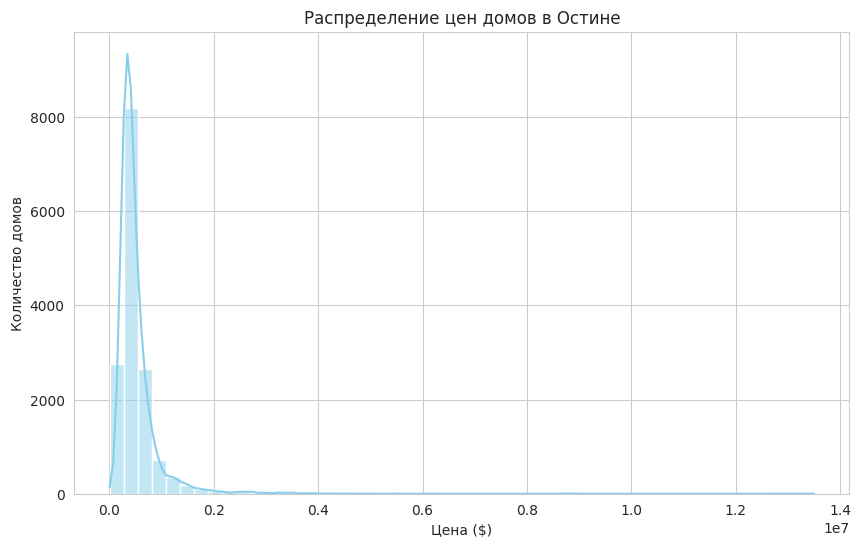

In [65]:
with ProgressBar():
    prices = df_dropped['latestPrice'].compute()

sns.histplot(prices, bins=50, kde=True, color='skyblue')
plt.title("Распределение цен домов в Остине")
plt.xlabel("Цена ($)")
plt.ylabel("Количество домов")
plt.show()

In [70]:
import numpy as np

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


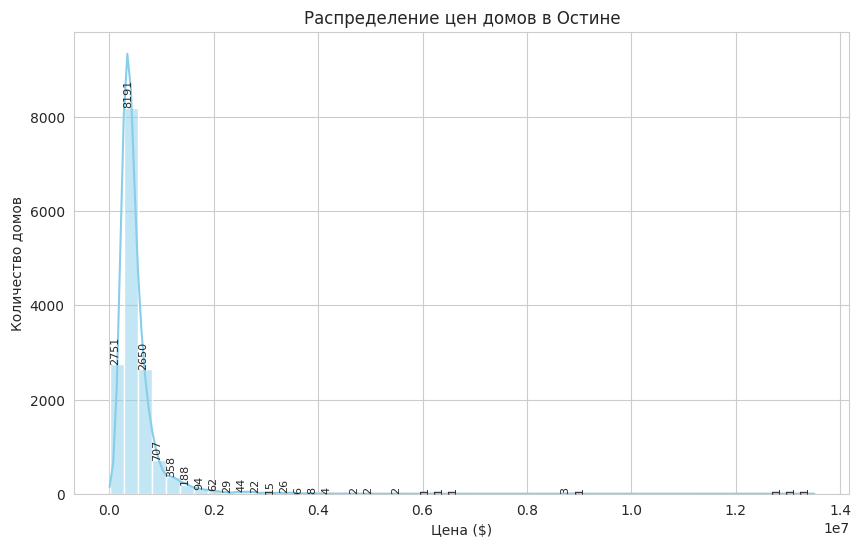

In [77]:
with ProgressBar():
    prices = df_dropped['latestPrice'].compute()

sns.histplot(prices, bins=50, kde=True, color='skyblue')
plt.title("Распределение цен домов в Остине")
plt.xlabel("Цена ($)")
plt.ylabel("Количество домов")

# Подписи на столбцах гистограммы
counts, bins_edges = np.histogram(prices, bins=50)
for count, edge in zip(counts, bins_edges):
    if count > 0:
        plt.text(edge, count, str(count), rotation=90, va='bottom', fontsize=8)

plt.show()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_775/157432720.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_sqft_by_zip.index.astype(str), y=avg_price_sqft_by_zip.values, palette="viridis")


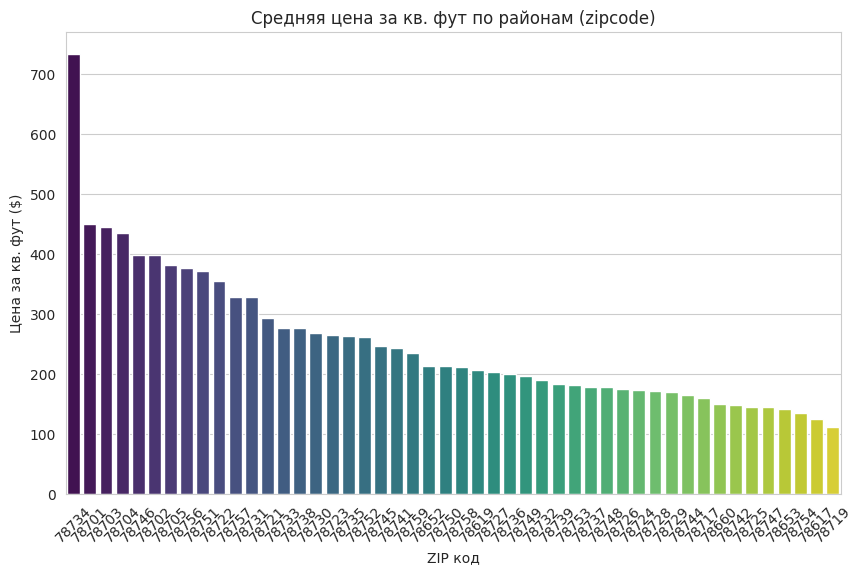

In [66]:
with ProgressBar():
    price_per_sqft = df_dropped['latestPrice'] / df_dropped['livingAreaSqFt']
    df_dropped['price_per_sqft'] = price_per_sqft
    avg_price_sqft_by_zip = df_dropped.groupby('zipcode')['price_per_sqft'].mean().compute()

avg_price_sqft_by_zip = avg_price_sqft_by_zip.sort_values(ascending=False)

sns.barplot(x=avg_price_sqft_by_zip.index.astype(str), y=avg_price_sqft_by_zip.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Средняя цена за кв. фут по районам (zipcode)")
plt.xlabel("ZIP код")
plt.ylabel("Цена за кв. фут ($)")
plt.show()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_775/2650087466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_price_sqft_by_zip.index.astype(str), y=avg_price_sqft_by_zip.values, palette="viridis")


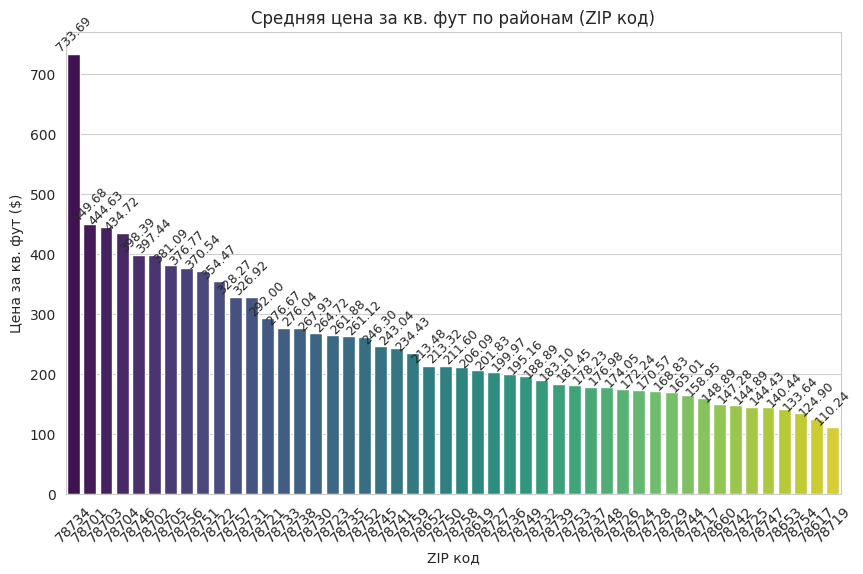

In [76]:
with ProgressBar():
    price_per_sqft = df_dropped['latestPrice'] / df_dropped['livingAreaSqFt']
    df_dropped['price_per_sqft'] = price_per_sqft
    avg_price_sqft_by_zip = df_dropped.groupby('zipcode')['price_per_sqft'].mean().compute()

avg_price_sqft_by_zip = avg_price_sqft_by_zip.sort_values(ascending=False)

ax = sns.barplot(x=avg_price_sqft_by_zip.index.astype(str), y=avg_price_sqft_by_zip.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Средняя цена за кв. фут по районам (ZIP код)")
plt.xlabel("ZIP код")
plt.ylabel("Цена за кв. фут ($)")

# Подписи над столбцами
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, rotation=45)

plt.show()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


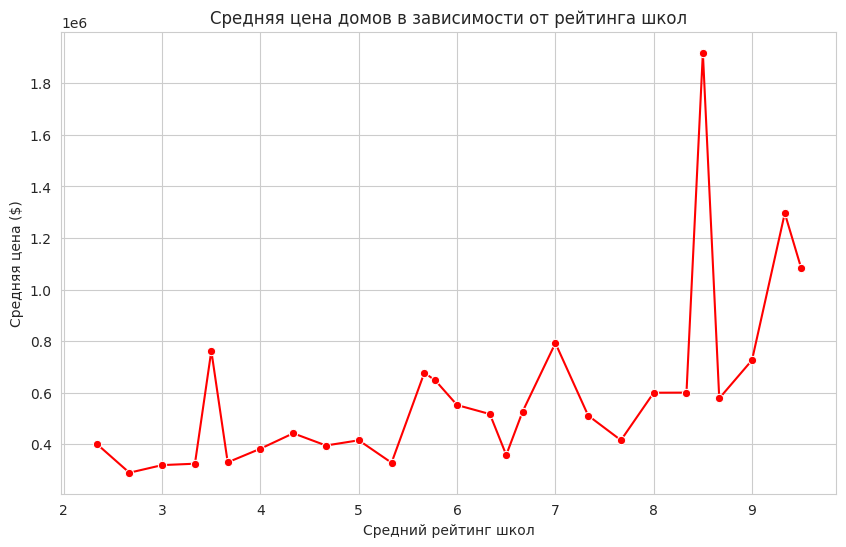

In [67]:
with ProgressBar():
    school_price = df_dropped.groupby('avgSchoolRating')['latestPrice'].mean().compute()

sns.lineplot(x=school_price.index, y=school_price.values, marker='o', color='red')
plt.title("Средняя цена домов в зависимости от рейтинга школ")
plt.xlabel("Средний рейтинг школ")
plt.ylabel("Средняя цена ($)")
plt.show()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


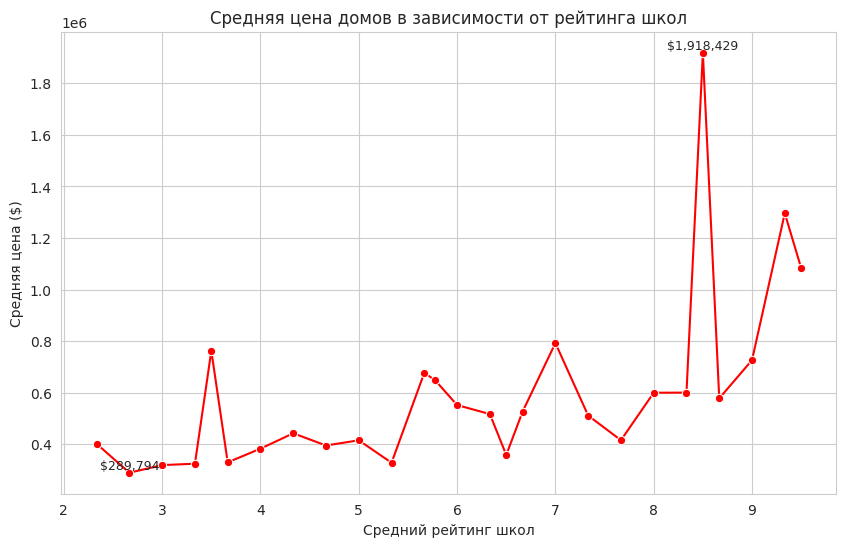

In [79]:
with ProgressBar():
    school_price = df_dropped.groupby('avgSchoolRating')['latestPrice'].mean().compute()

ax = sns.lineplot(x=school_price.index, y=school_price.values, marker='o', color='red')
plt.title("Средняя цена домов в зависимости от рейтинга школ")
plt.xlabel("Средний рейтинг школ")
plt.ylabel("Средняя цена ($)")

# Подписи только для мин и макс
min_idx = school_price.idxmin()
max_idx = school_price.idxmax()
for x, y in zip([min_idx, max_idx], [school_price[min_idx], school_price[max_idx]]):
    ax.text(x, y, f"${y:,.0f}", ha='center', va='bottom', fontsize=9)

plt.show()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


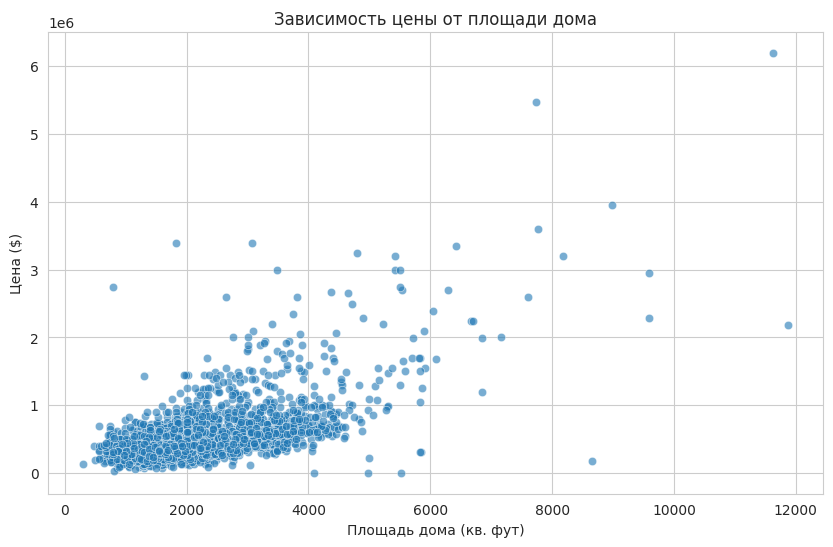

In [68]:
with ProgressBar():
    sample_df = df_dropped[['latestPrice','livingAreaSqFt']].sample(frac=0.2).compute()  # берём случайные 20% для скорости

sns.scatterplot(x='livingAreaSqFt', y='latestPrice', data=sample_df, alpha=0.6)
plt.title("Зависимость цены от площади дома")
plt.xlabel("Площадь дома (кв. фут)")
plt.ylabel("Цена ($)")
plt.show()

## Аналитика по школам

In [86]:
df_dropped.groupby('avgSchoolRating')['latestPrice'].count().compute()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


,latestPrice
avgSchoolRating,
2.333333,65
2.666667,206
3.000000,622
3.333333,1228
3.500000,2
3.666667,970
4.000000,1138
4.333333,736
4.666667,503


In [87]:
school_counts = df_dropped.groupby('avgSchoolRating')['latestPrice'].count().compute()

# Берём группы, где меньше 50 домов
small_groups = school_counts[school_counts < 50]
small_groups

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


,latestPrice
avgSchoolRating,
3.5,2
6.5,2
8.5,7
9.5,27


In [88]:
school_stats = df_dropped.groupby('avgSchoolRating')['latestPrice'].agg(
    ['mean','median']
).compute()

school_stats.loc[small_groups.index]

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


latestPrice           
                         mean     median
avgSchoolRating                         
3.5              7.623750e+05   762375.0
6.5              3.584950e+05   358495.0
8.5              1.918429e+06  1499000.0
9.5              1.083219e+06  1002000.0

In [89]:
rating_85 = df_dropped[df_dropped['avgSchoolRating'] == 8.5].compute()

rating_85[['latestPrice','livingAreaSqFt','lotSizeSqFt','homeType','zipcode']]

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


,latestPrice,livingAreaSqFt,lotSizeSqFt,homeType,zipcode
6098,945000.0,3232.0,14374.8,Single Family,78746
6113,2500000.0,7053.0,27878.4,Single Family,78746
6117,1499000.0,4754.0,72309.6,Single Family,78746
6285,1190000.0,3168.0,24393.6,Single Family,78746
6291,1295000.0,3815.0,12632.4,Single Family,78746
13281,2500000.0,4937.0,17424.0,Single Family,78746
13964,3500000.0,10484.0,259182.0,Vacant Land,78746


 В 3.5 и 6.5 всего 2 дома, поэтому невозможно здраво оценивать зависимость
8.5 - действительно дорогая группа, как и 9.5
После рейтинга 8 начинается премиальный сегмент рынка.

In [96]:
# Считаем количество домов
school_counts = df_dropped.groupby('avgSchoolRating')['latestPrice'].count().compute()

# Берём рейтинги, где >= 50 домов
valid_ratings = school_counts[school_counts >= 50].index

# Фильтруем датафрейм
df_filtered = df_dropped[df_dropped['avgSchoolRating'].isin(valid_ratings)]

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


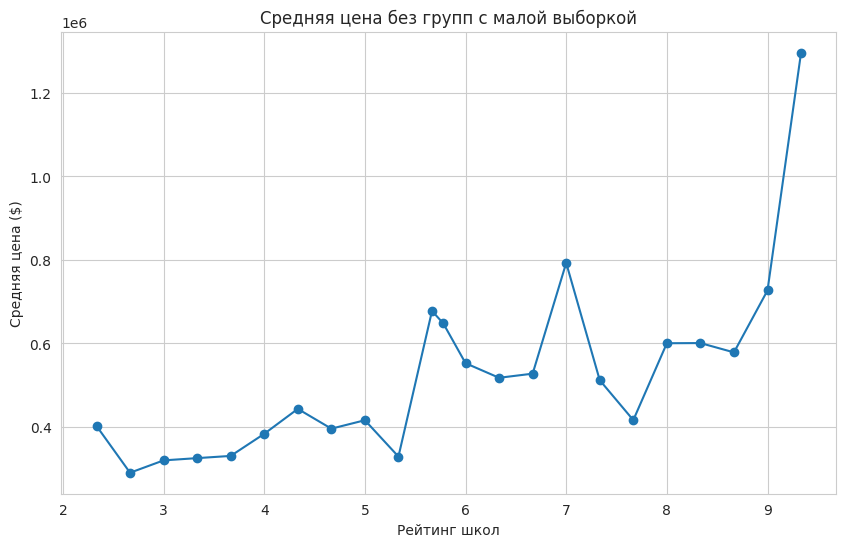

In [97]:
import matplotlib.pyplot as plt

school_price_filtered = df_filtered.groupby('avgSchoolRating')['latestPrice'].mean().compute()

plt.figure()
plt.plot(school_price_filtered.index, school_price_filtered.values, marker='o')
plt.title("Средняя цена без групп с малой выборкой")
plt.xlabel("Рейтинг школ")
plt.ylabel("Средняя цена ($)")
plt.show()

In [100]:
df_no_outliers[['avgSchoolRating','latestPrice']].corr().compute()

/usr/local/lib/python3.12/dist-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.t

,avgSchoolRating,latestPrice
avgSchoolRating,1.000000,0.455321
latestPrice,0.455321,1.000000


## Аналитика


In [14]:
import dask.dataframe as dd

df = dd.read_csv("austinHousingData.csv")

columns = [
    "latestPrice",
    "livingAreaSqFt",
    "lotSizeSqFt",
    "numOfBedrooms",
    "numOfBathrooms",
    "numOfStories",
    "avgSchoolRating",
    "yearBuilt",
    "propertyTaxRate"
]

df_numeric = df[columns]

In [15]:
df_corr = df_numeric.compute()

In [16]:
corr_matrix = df_corr.corr()
corr_matrix

,latestPrice,livingAreaSqFt,lotSizeSqFt,numOfBedrooms,numOfBathrooms,numOfStories,avgSchoolRating,yearBuilt,propertyTaxRate
latestPrice,1.000000,0.467034,0.020940,0.299839,0.504738,0.200555,0.293101,0.059692,-0.062179
livingAreaSqFt,0.467034,1.000000,0.006954,0.499993,0.569282,0.348002,0.373856,0.283752,0.062476
lotSizeSqFt,0.020940,0.006954,1.000000,0.005255,0.010426,0.008375,0.005768,-0.012240,-0.001985
numOfBedrooms,0.299839,0.499993,0.005255,1.000000,0.616122,0.327019,0.304741,0.275688,0.098455
numOfBathrooms,0.504738,0.569282,0.010426,0.616122,1.000000,0.551764,0.348892,0.430429,0.066139
numOfStories,0.200555,0.348002,0.008375,0.327019,0.551764,1.000000,0.222250,0.369571,0.057537
avgSchoolRating,0.293101,0.373856,0.005768,0.304741,0.348892,0.222250,1.000000,0.134781,0.184755
yearBuilt,0.059692,0.283752,-0.012240,0.275688,0.430429,0.369571,0.134781,1.000000,0.118247
propertyTaxRate,-0.062179,0.062476,-0.001985,0.098455,0.066139,0.057537,0.184755,0.118247,1.000000


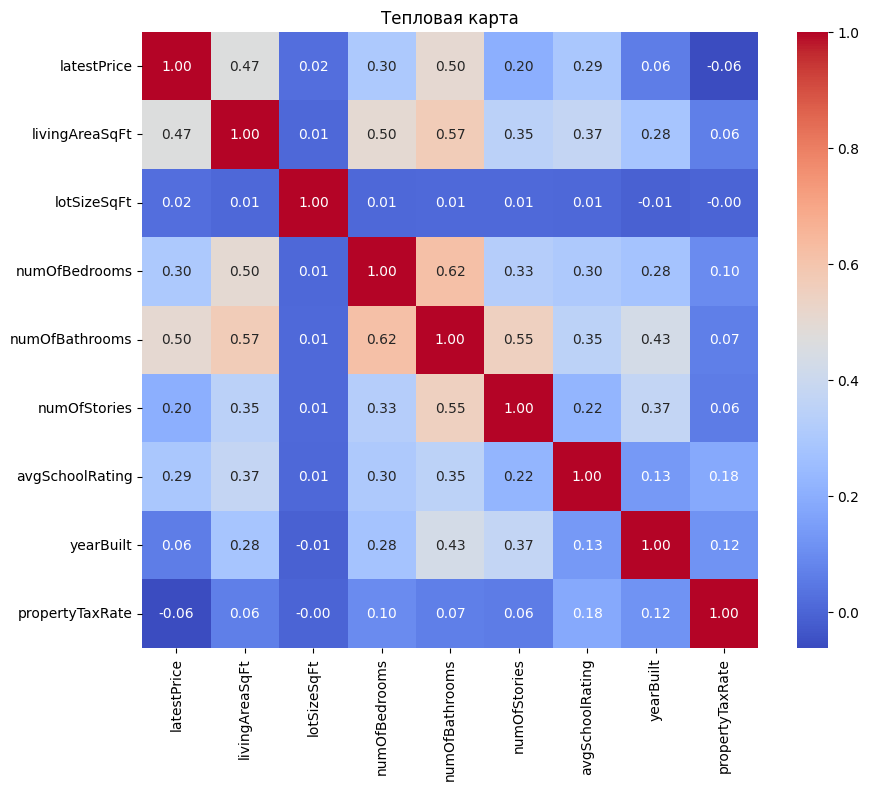

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Тепловая карта")

plt.show()

Для анализа взаимосвязей между характеристиками недвижимости была построена тепловая карта корреляций.

Наиболее сильная зависимость наблюдается между площадью дома (livingAreaSqFt) и ценой (latestPrice), что является ожидаемым результатом для рынка недвижимости.

Также наблюдается умеренная корреляция между количеством спален и ванных комнат и стоимостью дома.

Рейтинг школ оказывает менее выраженное влияние на стоимость недвижимости.